In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
train = pd.read_csv(r'D:\Projects\DataScience\News Topic Classifier\train.csv')
test = pd.read_csv(r'D:\Projects\DataScience\News Topic Classifier\test.csv')

train.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [7]:
train.info()
train['Class Index'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Class Index  120000 non-null  int64
 1   Title        120000 non-null  str  
 2   Description  120000 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.7 MB


Class Index
3    30000
4    30000
2    30000
1    30000
Name: count, dtype: int64

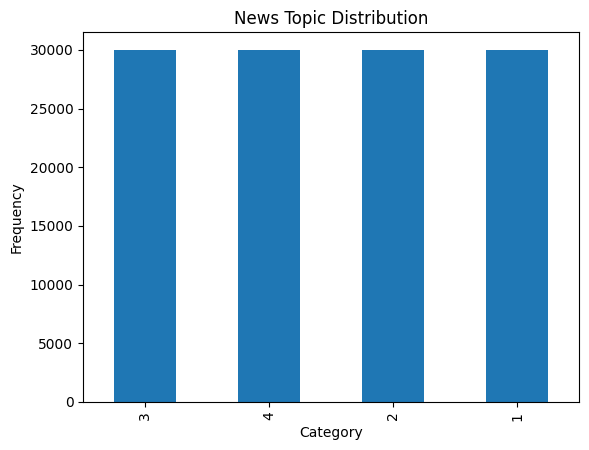

In [8]:
plt.figure()
train['Class Index'].value_counts().plot(kind='bar')
plt.title('News Topic Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

In [9]:
train['content'] = train['Title'] + " " + train['Description']
test['content'] = test['Title'] + " " + test['Description']

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

train['clean_text'] = train['content'].apply(clean_text)
test['clean_text'] = test['content'].apply(clean_text)

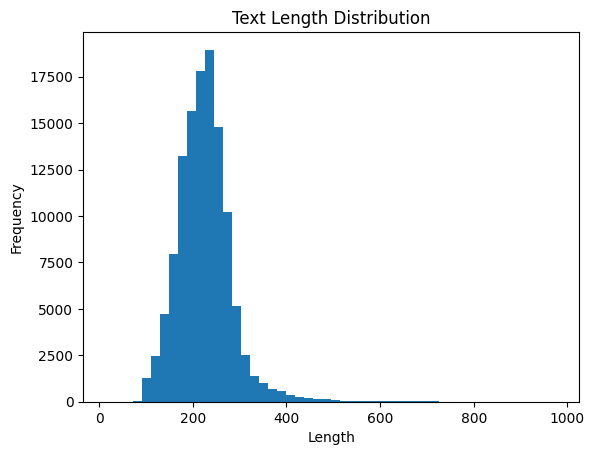

In [11]:
train['length'] = train['clean_text'].apply(len)

plt.figure()
plt.hist(train['length'], bins=50)
plt.title('Text Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

In [12]:
X_train = train['clean_text']
y_train = train['Class Index']

X_test = test['clean_text']
y_test = test['Class Index']

In [14]:
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [15]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

In [16]:
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

Accuracy:  0.9032894736842105

Classification Report:

              precision    recall  f1-score   support

           1       0.92      0.90      0.91      1900
           2       0.95      0.97      0.96      1900
           3       0.87      0.87      0.87      1900
           4       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



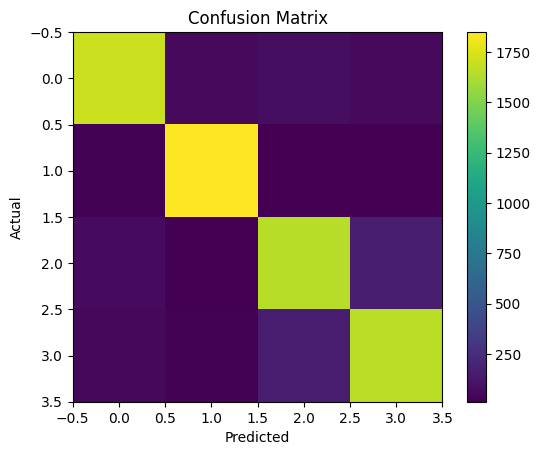

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()
plt.show()

In [18]:
def predict_news_category(text):
    cleaned = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    mapping = {
        1: "World",
        2: "Sports",
        3: "Business",
        4: "Sci/Tech"
    }

    return mapping[prediction]

In [20]:
user_text = input("Enter news text: ")

print("\nInput:", user_text)
print("Category:", predict_news_category(user_text))


Input: Team wins championship after thrilling final match
Category: Sports
